--- Đang khởi tạo dữ liệu giả lập ---
Đã tạo file dữ liệu giả lập 'raw_sales.csv' thành công!

Kích thước tập Train: (376, 30, 1)
Kích thước tập Test: (94, 30, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)


--- Đang huấn luyện mô hình RNN ---
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 0.1383 - val_loss: 0.0081
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0867 - val_loss: 0.0115
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0505 - val_loss: 0.0081
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0409 - val_loss: 0.0183
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0354 - val_loss: 0.0057
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0285 - val_loss: 0.0122
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0221 - val_loss: 0.0080
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0238 - val_loss: 0.0048
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0193 - val_loss: 0.0046
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0169 - val_loss: 0.0059
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0180 - val_loss: 0.0066
Epoch 12/20
12/12 ━━━━━━

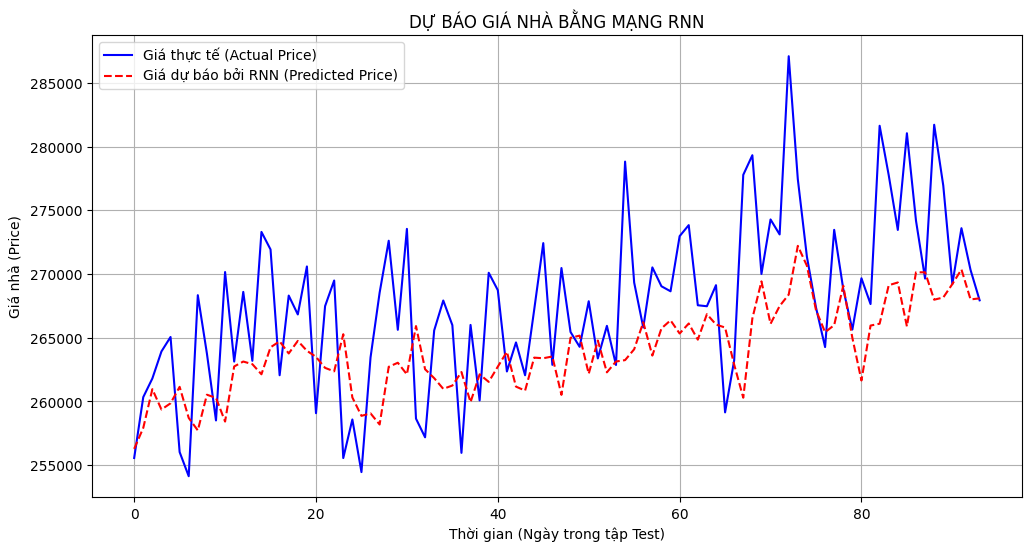

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# =====================================================================
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP (Vì bạn chưa có file raw_sales.csv)
# (Khi nào có file thật, bạn chỉ cần xóa đoạn này và dùng pd.read_csv)
# =====================================================================
print("--- Đang khởi tạo dữ liệu giả lập ---")
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=500, freq="D")
# Giả lập giá nhà có xu hướng tăng kèm biến động
mock_prices = 200000 + np.arange(500) * 150 + np.random.normal(0, 5000, 500)

# Tạo DataFrame mô phỏng cấu trúc raw_sales.csv
df = pd.DataFrame({
    'datesold': dates,
    'price': mock_prices,
    'bedrooms': np.random.randint(1, 5, size=500)
})
# Lưu ra file csv để giống hệt quy trình làm bài của bạn
df.to_csv('raw_sales.csv', index=False)
print("Đã tạo file dữ liệu giả lập 'raw_sales.csv' thành công!\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# =====================================================================
# 1. Đọc dữ liệu (Sau này có file thật của thầy cô, bạn bắt đầu từ dòng này)
data = pd.read_csv('raw_sales.csv')

# 2. Chuyển cột thời gian về đúng định dạng và sắp xếp theo thứ tự thời gian
data['datesold'] = pd.to_datetime(data['datesold'])
data = data.sort_values('datesold')

# 3. Trích xuất chuỗi giá nhà (price) để dự báo
price_data = data['price'].values.reshape(-1, 1)

# 4. Chuẩn hóa dữ liệu về khoảng [0, 1] (Bắt buộc đối với mạng RNN/LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(price_data)

# 5. Hàm tạo cấu trúc dữ liệu chuỗi (Time-step) cho RNN
# Ví dụ: Dùng giá của n_steps ngày trước đó để dự báo giá ngày tiếp theo
def create_dataset(dataset, n_steps):
    X, y = [], []
    for i in range(len(dataset) - n_steps):
        X.append(dataset[i:(i + n_steps), 0])
        y.append(dataset[i + n_steps, 0])
    return np.array(X), np.array(y)

N_STEPS = 30 # Dùng 30 ngày trước để đoán ngày tiếp theo
X, y = create_dataset(scaled_data, N_STEPS)

# Reshape X sang định dạng 3D theo yêu cầu của Keras RNN: [samples, timesteps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 6. Chia dữ liệu thành tập Train (80%) và Test (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH RNN
# =====================================================================
model = Sequential([
    # Lớp RNN đầu tiên
    SimpleRNN(units=50, activation='tanh', return_sequences=True, input_shape=(N_STEPS, 1)),
    Dropout(0.2),

    # Lớp RNN thứ hai
    SimpleRNN(units=50, activation='tanh'),
    Dropout(0.2),

    # Lớp Output dự báo giá (Bài toán hồi quy nên ra 1 giá trị duy nhất)
    Dense(units=1)
])

# Compile mô hình với loss function là MSE (Mean Squared Error) phù hợp cho dự báo giá
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (TRAINING)
# =====================================================================
print("\n--- Đang huấn luyện mô hình RNN ---")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


# =====================================================================
# BƯỚC 5: ĐÁNH GIÁ VÀ DỰ BÁO (PREDICTION)
# =====================================================================
# Dự báo trên tập Test
predictions = model.predict(X_test)

# Chuyển ngược dữ liệu từ khoảng [0, 1] về lại đơn vị giá gốc ban đầu
predictions = scaler.inverse_transform(predictions)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Trực quan hóa kết quả bằng biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, color='blue', label='Giá thực tế (Actual Price)')
plt.plot(predictions, color='red', linestyle='--', label='Giá dự báo bởi RNN (Predicted Price)')
plt.title('DỰ BÁO GIÁ NHÀ BẰNG MẠNG RNN')
plt.xlabel('Thời gian (Ngày trong tập Test)')
plt.ylabel('Giá nhà (Price)')
plt.legend()
plt.grid(True)
plt.show()

--- Đang tạo dữ liệu giả lập BTC_DATA.csv ---
Đã tạo file dữ liệu giả lập 'BTC_DATA.csv' thành công!

Kích thước tập Train: (471, 45, 1)
Kích thước tập Test: (84, 45, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 45, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)


--- Đang chạy huấn luyện mạng LSTM ---
Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.1471 - val_loss: 0.0105
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0188 - val_loss: 0.0233
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0115 - val_loss: 0.0128
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0093 - val_loss: 0.0109
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0088 - val_loss: 0.0115
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0080 - val_loss: 0.0092
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0063 - val_loss: 0.0073
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0070 - val_loss: 0.0065
Epoch 9/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0072 - val_loss: 0.0062
Epoch 10/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0071 - val_loss: 0.0058
Epoch 11/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0064 - val_loss: 0.0054
Epoch 12/25
15/15 ━━━━━

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


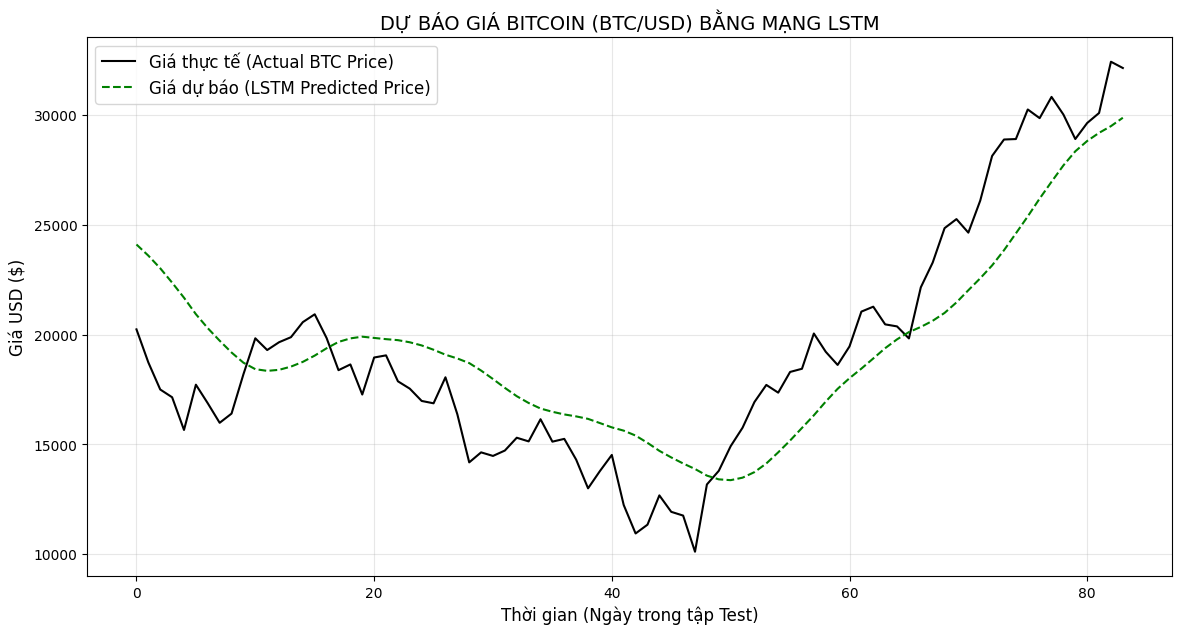

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================================
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP (Mô phỏng BTC_DATA.csv)
# (Khi có file thật từ giảng viên, bạn hãy xóa hoặc comment đoạn này)
# =====================================================================
print("--- Đang tạo dữ liệu giả lập BTC_DATA.csv ---")
np.random.seed(7)
dates = pd.date_range(start="2022-01-01", periods=600, freq="D")

# Giả lập giá Bitcoin biến động mạnh bằng mô hình Random Walk
start_price = 40000
price_changes = np.random.normal(loc=50, scale=1200, size=600)
mock_btc_prices = start_price + np.cumsum(price_changes)

# Tạo DataFrame mô phỏng cấu trúc file bài tập
df_btc = pd.DataFrame({
    'date': dates,
    'priceUSD': mock_btc_prices
})
df_btc.to_csv('BTC_DATA.csv', index=False)
print("Đã tạo file dữ liệu giả lập 'BTC_DATA.csv' thành công!\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU CHUỖI THỜI GIAN
# =====================================================================
# 1. Đọc dữ liệu thực tế (Bắt đầu từ đây khi bạn có file của giảng viên)
data = pd.read_csv('BTC_DATA.csv')

# 2. Đảm bảo dữ liệu được sắp xếp theo trình tự thời gian tăng dần
if 'date' in data.columns:
    data['date'] = pd.to_datetime(data['date'])
    data = data.sort_values('date')

# 3. Lấy chuỗi giá trị priceUSD
btc_prices = data['priceUSD'].values.reshape(-1, 1)

# 4. Chuẩn hóa dữ liệu về khoảng [0, 1] để tối ưu cho thuật toán mạng nơ-ron
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(btc_prices)

# 5. Hàm tạo tập dữ liệu trượt (Lookback Window)
# Sử dụng dữ liệu của `n_steps` ngày liên tiếp trước đó làm đầu vào (X) để đoán ngày tiếp theo (y)
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps), 0])
        y.append(data[i + n_steps, 0])
    return np.array(X), np.array(y)

N_STEPS = 45 # Dùng dữ liệu 45 ngày trước để dự báo ngày thứ 46
X, y = create_sequences(scaled_prices, N_STEPS)

# Định hình cấu trúc đầu vào 3D cho LSTM: [samples, timesteps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 6. Chia dữ liệu: 85% để huấn luyện (Train), 15% để kiểm thử (Test)
train_size = int(len(X) * 0.85)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH LSTM (BIẾN THỂ CẢI TIẾN CỦA RNN)
# =====================================================================
model = Sequential([
    # Lớp LSTM thứ nhất (Cần return_sequences=True để truyền chuỗi cho lớp sau)
    LSTM(units=64, return_sequences=True, input_shape=(N_STEPS, 1)),
    Dropout(0.2), # Hạn chế Overfitting

    # Lớp LSTM thứ hai
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),

    # Lớp Fully Connected (Dense) cho ra 1 giá trị dự báo duy nhất
    Dense(units=1)
])

# Sử dụng Adam Optimizer và hàm lỗi MSE để tối ưu bài toán hồi quy (Regression)
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (TRAIN)
# =====================================================================
print("\n--- Đang chạy huấn luyện mạng LSTM ---")
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


# =====================================================================
# BƯỚC 5: ĐÁNH GIÁ VÀ TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
# Thực hiện dự báo trên tập Test
raw_predictions = model.predict(X_test)

# Chuyển đổi ngược (Inverse Transform) từ khoảng [0, 1] về mệnh giá USD thực tế
predicted_prices = scaler.inverse_transform(raw_predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Vẽ biểu đồ so sánh kết quả
plt.figure(figsize=(14, 7))
plt.plot(actual_prices, color='black', label='Giá thực tế (Actual BTC Price)')
plt.plot(predicted_prices, color='green', linestyle='--', label='Giá dự báo (LSTM Predicted Price)')
plt.title('DỰ BÁO GIÁ BITCOIN (BTC/USD) BẰNG MẠNG LSTM', fontsize=14)
plt.xlabel('Thời gian (Ngày trong tập Test)', fontsize=12)
plt.ylabel('Giá USD ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

--- Đang tạo dữ liệu giả lập household_power_consumption.txt ---
Đã tạo file dữ liệu giả lập thành công!

Kích thước tập Train: (752, 60, 1)
Kích thước tập Test: (188, 60, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)


--- Đang chạy huấn luyện mạng GRU ---
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - loss: 0.1205 - val_loss: 0.0550
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0241 - val_loss: 0.0156
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0165 - val_loss: 0.0102
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0113 - val_loss: 0.0081
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - loss: 0.0091 - val_loss: 0.0071
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 0.0082 - val_loss: 0.0067
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0083 - val_loss: 0.0065
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0084 - val_loss: 0.0064
Epoch 9/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0085 - val_loss: 0.0064
Epoch 10/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0083 - val_loss: 0.0063
Epoch 11/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0082 - val_loss: 0.0063
Epoch 12/15
12/12 

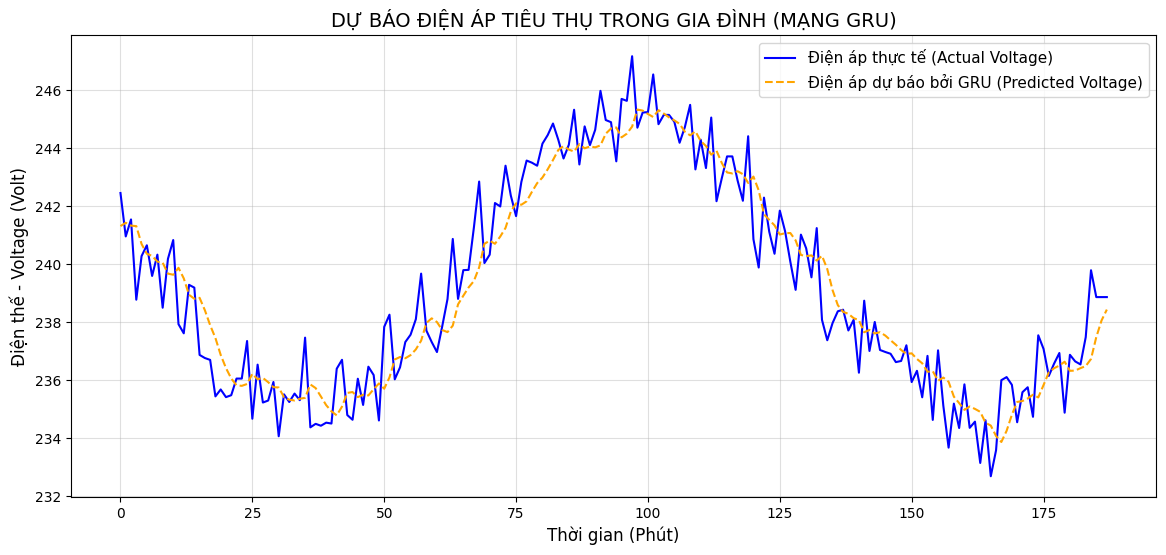

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# =====================================================================
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP (Mô phỏng file household_power_consumption.txt)
# (Khi nào có file thật từ giảng viên, bạn hãy xóa hoặc comment đoạn này)
# =====================================================================
print("--- Đang tạo dữ liệu giả lập household_power_consumption.txt ---")
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=1000, freq="min") # Giả lập dữ liệu theo từng phút

# Tạo chuỗi điện áp (Voltage) xoay quanh mức 230V - 250V kèm nhiễu
mock_voltage = 240 + np.sin(np.linspace(0, 50, 1000)) * 5 + np.random.normal(0, 1, 1000)

# Cố tình chèn một vài ký tự '?' (dữ liệu thiếu) để mô phỏng chính xác dataset gốc
mock_voltage_with_nan = [str(v) if np.random.rand() > 0.02 else '?' for v in mock_voltage]

# Tạo DataFrame phân tách bằng dấu chấm phẩy ';' giống hệt file thực tế
df_power = pd.DataFrame({
    'Date': dates.strftime('%d/%m/%Y'),
    'Time': dates.strftime('%H:%M:%S'),
    'Voltage': mock_voltage_with_nan,
    'Global_active_power': np.random.uniform(0.1, 5.0, 1000)
})
df_power.to_csv('household_power_consumption.txt', sep=';', index=False)
print("Đã tạo file dữ liệu giả lập thành công!\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU VÀ XỬ LÝ DỮ LIỆU KHUYẾT THIẾU
# =====================================================================
# 1. Đọc file .txt phân tách bằng dấu ';' và ép các ký tự '?' thành giá trị NaN (Not a Number)
data = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)

# 2. Xử lý giá trị bị khuyết (NaN) bằng phương pháp điền giá trị của dòng phía trước (Forward Fill)
data['Voltage'] = data['Voltage'].ffill()

# 3. Lấy chuỗi dữ liệu Voltage
voltage_data = data['Voltage'].values.astype('float32').reshape(-1, 1)

# 4. Chuẩn hóa dữ liệu về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_voltage = scaler.fit_transform(voltage_data)

# 5. Hàm tạo dữ liệu chuỗi thời gian trượt
def create_sequences(dataset, n_steps):
    X, y = [], []
    for i in range(len(dataset) - n_steps):
        X.append(dataset[i:(i + n_steps), 0])
        y.append(dataset[i + n_steps, 0])
    return np.array(X), np.array(y)

N_STEPS = 60 # Sử dụng dữ liệu của 60 phút trước đó để dự báo phút tiếp theo
X, y = create_sequences(scaled_voltage, N_STEPS)

# Reshape X sang định dạng 3D cho mạng hồi quy: [samples, timesteps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 6. Chia dữ liệu thành Train (80%) và Test (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH MẠNG GRU
# =====================================================================
model = Sequential([
    # Lớp GRU thứ nhất
    GRU(units=50, return_sequences=True, input_shape=(N_STEPS, 1)),
    Dropout(0.1),

    # Lớp GRU thứ hai
    GRU(units=50, return_sequences=False),
    Dropout(0.1),

    # Lớp đầu ra cho bài toán dự báo giá trị liên tục (Regression)
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (TRAIN)
# =====================================================================
print("\n--- Đang chạy huấn luyện mạng GRU ---")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


# =====================================================================
# BƯỚC 5: DỰ BÁO VÀ TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
# Tiến hành dự báo trên tập dữ liệu Test
predictions = model.predict(X_test)

# Chuyển ngược kết quả chuẩn hóa về đơn vị Điện áp thực tế (Volt)
predicted_voltage = scaler.inverse_transform(predictions)
actual_voltage = scaler.inverse_transform(y_test.reshape(-1, 1))

# Vẽ đồ thị so sánh kết quả thực tế và dự báo
plt.figure(figsize=(14, 6))
plt.plot(actual_voltage[:200], color='blue', label='Điện áp thực tế (Actual Voltage)')
plt.plot(predicted_voltage[:200], color='orange', linestyle='--', label='Điện áp dự báo bởi GRU (Predicted Voltage)')
plt.title('DỰ BÁO ĐIỆN ÁP TIÊU THỤ TRONG GIA ĐÌNH (MẠNG GRU)', fontsize=14)
plt.xlabel('Thời gian (Phút)', fontsize=12)
plt.ylabel('Điện thế - Voltage (Volt)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.show()

--- Đang tạo dữ liệu giả lập NIFTY_stock_market.csv ---
Đã tạo file dữ liệu giả lập thành công!

Kích thước tập Train: (592, 60, 1)
Kích thước tập Test: (148, 60, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Đang chạy huấn luyện mạng LSTM với Early Stopping ---
Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0304 - val_loss: 0.0260
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0069 - val_loss: 0.0124
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0045 - val_loss: 0.0029
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0043 - val_loss: 0.0029
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 9/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 10/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 11/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0042 - val_loss: 0.0022
Epoc

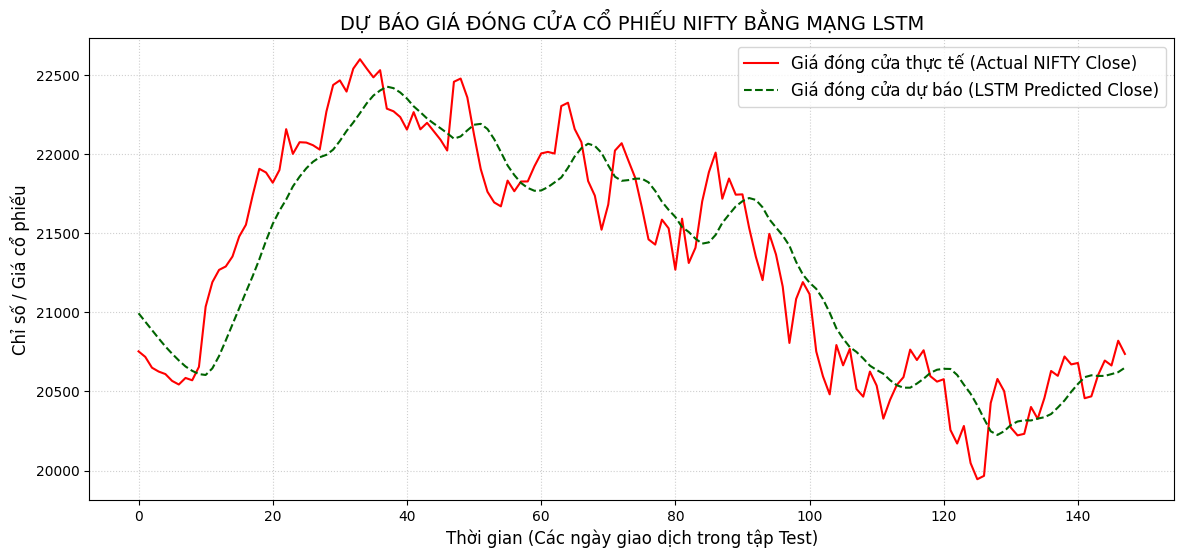

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================================
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP (Mô phỏng NIFTY_stock_market.csv)
# (Xóa hoặc comment đoạn này khi bạn nhận được file chuẩn từ giảng viên)
# =====================================================================
print("--- Đang tạo dữ liệu giả lập NIFTY_stock_market.csv ---")
np.random.seed(101)
dates = pd.date_range(start="2021-01-01", periods=800, freq="B") # "B" đại diện cho Business days (không tính thứ 7, CN)

# Giả lập xu hướng tăng giảm của chỉ số chứng khoán NIFTY
start_index = 15000
shocks = np.random.normal(loc=5, scale=150, size=800)
mock_close_prices = start_index + np.cumsum(shocks)

df_nifty = pd.DataFrame({
    'Date': dates,
    'Close': mock_close_prices,
    'Volume': np.random.randint(100000, 900000, size=800)
})
df_nifty.to_csv('NIFTY_stock_market.csv', index=False)
print("Đã tạo file dữ liệu giả lập thành công!\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU CHỨNG KHOÁN
# =====================================================================
# 1. Đọc dữ liệu (Bắt đầu từ đây khi chạy với file thật)
data = pd.read_csv('NIFTY_stock_market.csv')

# 2. Định dạng ngày tháng và sắp xếp tăng dần theo thời gian
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# 3. Lấy chuỗi giá đóng cửa (Close)
close_prices = data['Close'].values.reshape(-1, 1)

# 4. Chuẩn hóa dữ liệu về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_prices)

# 5. Hàm cắt chuỗi dữ liệu theo phương pháp cửa sổ trượt (Sliding Window)
def create_sequences(dataset, n_steps):
    X, y = [], []
    for i in range(len(dataset) - n_steps):
        X.append(dataset[i:(i + n_steps), 0])
        y.append(dataset[i + n_steps, 0])
    return np.array(X), np.array(y)

N_STEPS = 60 # Sử dụng giá đóng cửa của 60 ngày giao dịch trước đó để đoán ngày tiếp theo
X, y = create_sequences(scaled_close, N_STEPS)

# Thay đổi chiều dữ liệu sang 3D: [samples, timesteps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 6. Chia dữ liệu thành tập Train (80%) và Test (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: CÀI ĐẶT MẠNG LSTM DỰ BÁO CHỨNG KHOÁN
# =====================================================================
model = Sequential([
    # Lớp LSTM số 1
    LSTM(units=50, return_sequences=True, input_shape=(N_STEPS, 1)),
    Dropout(0.2),

    # Lớp LSTM số 2
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Lớp Output dự báo giá trị liên tục
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


# =====================================================================
# BƯỚC 4: CÀI ĐẶT EARLY STOPPING VÀ HUÂN LUYỆN
# =====================================================================
# Kỹ thuật nâng cao giúp dừng train nếu loss trên tập Test không giảm sau 5 epoch liên tiếp
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("--- Đang chạy huấn luyện mạng LSTM với Early Stopping ---")
history = model.fit(
    X_train, y_train,
    epochs=40, # Đặt số epoch lớn, Early Stopping sẽ tự ngắt khi tối ưu
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


# =====================================================================
# BƯỚC 5: DỰ BÁO VÀ HIỂN THỊ BIỂU ĐỒ KẾT QUẢ
# =====================================================================
# Dự báo
predictions = model.predict(X_test)

# Đưa giá trị dự báo và thực tế về mệnh giá gốc (Điểm số sàn NIFTY)
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Trực quan hóa kết quả bằng đồ thị đường
plt.figure(figsize=(14, 6))
plt.plot(actual_prices, color='red', label='Giá đóng cửa thực tế (Actual NIFTY Close)')
plt.plot(predicted_prices, color='darkgreen', linestyle='--', label='Giá đóng cửa dự báo (LSTM Predicted Close)')
plt.title('DỰ BÁO GIÁ ĐÓNG CỬA CỔ PHIẾU NIFTY BẰNG MẠNG LSTM', fontsize=14)
plt.xlabel('Thời gian (Các ngày giao dịch trong tập Test)', fontsize=12)
plt.ylabel('Chỉ số / Giá cổ phiếu', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Đọc dữ liệu thành công!
Đang huấn luyện mô hình...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.1420 - val_loss: 0.0076
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0709 - val_loss: 0.0075
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0468 - val_loss: 0.0059
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0392 - val_loss: 0.0097
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0268 - val_loss: 0.0052
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0248 - val_loss: 0.0019
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0216 - val_loss: 0.0022
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0179 - val_loss: 0.0011
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0146 - val_loss: 0.0019
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0135 - val_loss: 0.0013
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0126 - val_loss: 0.0015
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0117 - val_l

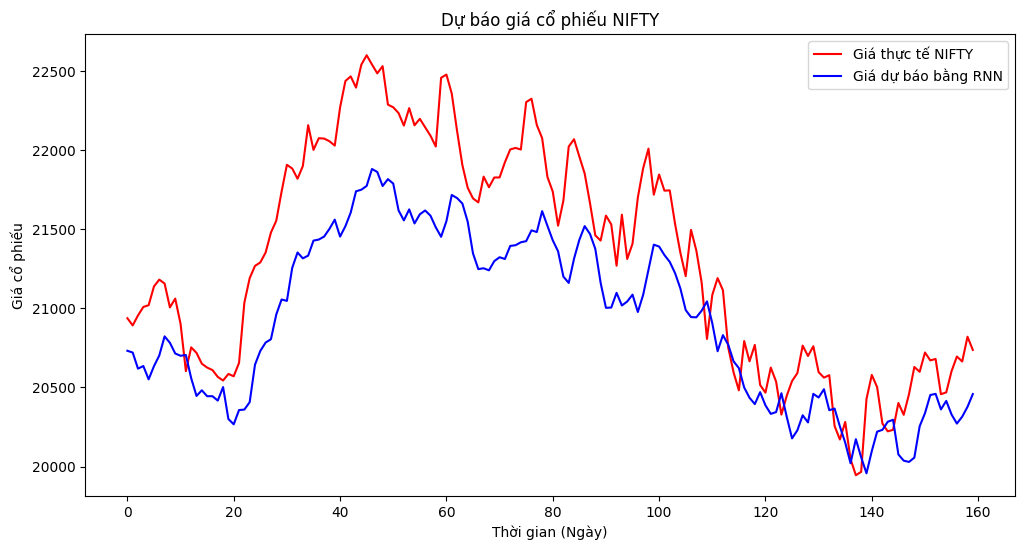

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout

# =================================================================
# 1. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# =================================================================
# Thay 'NIFTY_stock_market.csv' bằng đường dẫn file thực tế của bạn
try:
    df = pd.read_csv('NIFTY_stock_market.csv')
    print("Đọc dữ liệu thành công!")
except FileNotFoundError:
    print("Vui lòng tải file dữ liệu lên hoặc đổi lại tên file cho đúng.")

# Lấy cột giá đóng cửa 'Close' (giả định tên cột là 'Close' hoặc 'close')
# Cần reshape về dạng 2D array cho việc scale
data = df['Close'].values.reshape(-1, 1)

# Chuẩn hóa dữ liệu về khoảng [0, 1] vì RNN rất nhạy cảm với scale dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Chia tập train / test (ví dụ: 80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# =================================================================
# 2. TẠO CẤU TRÚC DỮ LIỆU CHUỖI THỜI GIAN (TIME SERIES)
# =================================================================
# Sử dụng n_steps ngày trước đó để dự báo cho ngày tiếp theo
def create_dataset(dataset, n_steps=60):
    X, y = [], []
    for i in range(n_steps, len(dataset)):
        X.append(dataset[i-n_steps:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

n_steps = 60  # Nhìn lại 60 ngày trước đó
X_train, y_train = create_dataset(train_data, n_steps)

# Reshape dữ liệu đầu vào thành 3D [samples, timesteps, features] theo yêu cầu của RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# =================================================================
# 3. XÂY DỰNG MÔ HÌNH RNN
# =================================================================
model = Sequential([
    # Lớp SimpleRNN thứ nhất
    SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    # Lớp SimpleRNN thứ hai
    SimpleRNN(units=50, return_sequences=False),
    Dropout(0.2),

    # Lớp Output dự báo 1 giá trị duy nhất
    Dense(units=1)
])

# Compile mô hình
model.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
print("Đang huấn luyện mô hình...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# =================================================================
# 4. DỰ BÁO TRÊN TẬP TEST
# =================================================================
# Chuẩn bị dữ liệu test (cần lấy thêm n_steps ngày cuối của tập train để dự báo cho những ngày đầu tập test)
inputs = scaled_data[len(scaled_data) - len(test_data) - n_steps:]
X_test, y_test = create_dataset(inputs, n_steps)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Dự báo
predicted_prices = model.predict(X_test)
# Chuyển ngược dữ liệu từ khoảng [0, 1] về giá trị gốc ban đầu
predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# =================================================================
# 5. TRỰC QUAN HÓA KẾT QUẢ
# =================================================================
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, color='red', label='Giá thực tế NIFTY')
plt.plot(predicted_prices, color='blue', label='Giá dự báo bằng RNN')
plt.title('Dự báo giá cổ phiếu NIFTY')
plt.xlabel('Thời gian (Ngày)')
plt.ylabel('Giá cổ phiếu')
plt.legend()
plt.show()